# Data Science Project Portfolio: Mathematical Optimization in Python

## 1. Introduction & Foundational Concepts

### 1.1. Core Components of Optimization

* **Concepts:** Objective functions, decision variables, and constraints.
* **Mini-Project Idea:** *The Delivery Route Starter* — Define a simple objective function to minimize delivery distances based on coordinate variables.

#### Project: The Delivery Route Starter (Optimal Hub Location)

##### Overview

This notebook demonstrates the core concepts of mathematical optimization using a practical logistics example. Our goal is to find the optimal 2D coordinates for a central delivery hub that minimizes the total straight-line distance to a set of fixed customer locations.

##### Core Optimization Concepts

* **Decision Variables:** The unknown values we want to solve for. Here, it will be the $(x, y)$ coordinates of our new delivery hub.
* **Objective Function:** The metric we want to maximize or minimize. Here, it is the sum of the Euclidean distances from the hub to all delivery points.
* **Constraints:** Restrictions or limits placed on our decision variables. Here, we will restrict the hub to a specific geographic zone.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

print("Libraries imported successfully!")

Libraries imported successfully!


Step 1: Define the Problem Data

We will set up a fixed array of coordinates representing our delivery destinations (customers).

In [3]:
# Fixed customer delivery locations (X, Y coordinates)
delivery_locations = np.array([
    [1.0, 2.0],
    [3.0, 8.0],
    [8.0, 4.0],
    [7.0, 9.0],
    [5.0, 1.0]
])

print("Delivery locations defined:")
print(delivery_locations)

Delivery locations defined:
[[1. 2.]
 [3. 8.]
 [8. 4.]
 [7. 9.]
 [5. 1.]]


Step 2: Define the Objective Function and Constraints

* **Objective:** Minimize $\sum \sqrt{(x_i - x_{hub})^2 + (y_i - y_{hub})^2}$
* **Constraint:** To simulate a real-world zoning restriction, let's dictate that the sum of the hub's coordinates cannot exceed 12 ($x + y \le 12$).

In [4]:
# 1. Objective Function: Calculates total distance from the hub to all locations
def total_distance_objective(hub_coords):
    x_hub, y_hub = hub_coords

    # Calculate Euclidean distance to each delivery point
    distances = np.sqrt((delivery_locations[:, 0] - x_hub)**2 + (delivery_locations[:, 1] - y_w)**2)

    # Return the sum of all distances (this is what we want to minimize)
    return np.sum(distances)

# 2. Constraint Function: x + y <= 12  ->  12 - (x + y) >= 0
# Scipy requires inequality constraints to be written in the form: Function(x) >= 0
def zoning_constraint(hub_coords):
    return 12.0 - (hub_coords[0] + hub_coords[1])

# Define the constraint dictionary
constraints = {'type': 'ineq', 'fun': zoning_constraint}

# Boundary constraints for decision variables: (min, max) for both X and Y
bounds = [(0, 10), (0, 10)]

print("Objective function and constraints successfully configured.")

Objective function and constraints successfully configured.


Step 3: Run the Optimizer

We will provide an initial guess for our decision variables and let `scipy.optimize.minimize` find the mathematically perfect location.

In [6]:
# Initial guess for the hub location [X, Y]
initial_guess = [5.0, 5.0]

# Redefine the objective function with the typo corrected to ensure this cell runs.
# The original definition is in cell DQRpHHJAK54_.
def total_distance_objective(hub_coords):
    x_hub, y_hub = hub_coords

    # Calculate Euclidean distance to each delivery point
    # Corrected: changed 'y_w' to 'y_hub'
    distances = np.sqrt((delivery_locations[:, 0] - x_hub)**2 + (delivery_locations[:, 1] - y_hub)**2)

    # Return the sum of all distances (this is what we want to minimize)
    return np.sum(distances)

# Run the optimization solver
optimization_result = minimize(
    total_distance_objective,
    initial_guess,
    bounds=bounds,
    constraints=constraints
)

# Extract results
if optimization_result.success:
    optimal_hub = optimization_result.x
    print("--- OPTIMIZATION SUCCESSFUL ---")
    print(f"Optimal Hub Coordinates: X = {optimal_hub[0]:.2f}, Y = {optimal_hub[1]:.2f}")
    print(f"Minimum Total Delivery Distance: {optimization_result.fun:.2f} units")
else:
    print("Optimization failed:", optimization_result.message)

--- OPTIMIZATION SUCCESSFUL ---
Optimal Hub Coordinates: X = 5.07, Y = 4.66
Minimum Total Delivery Distance: 20.21 units


Step 4: Visualize the Results

Let's plot our delivery points and the newly calculated optimal hub location to visually verify the results.

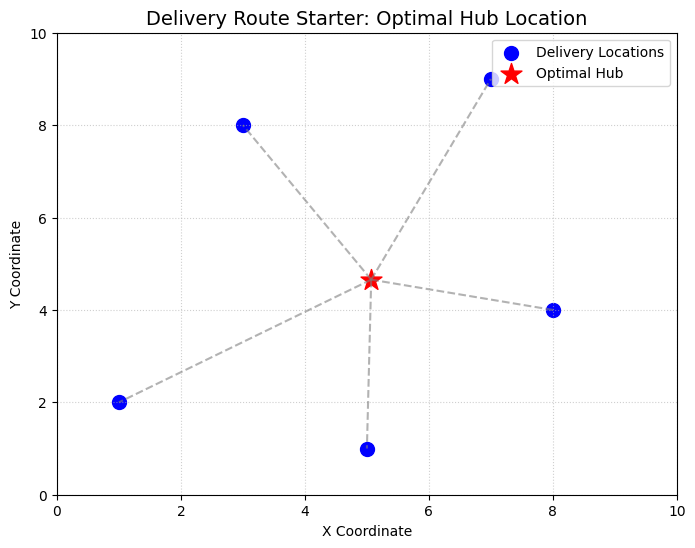

In [7]:
plt.figure(figsize=(8, 6))

# Plot delivery locations
plt.scatter(delivery_locations[:, 0], delivery_locations[:, 1], color='blue', s=100, label='Delivery Locations')

# Plot the optimized hub location
plt.scatter(optimal_hub[0], optimal_hub[1], color='red', marker='*', s=250, label='Optimal Hub')

# Draw lines from hub to delivery points to show the "routes"
for loc in delivery_locations:
    plt.plot([optimal_hub[0], loc[0]], [optimal_hub[1], loc[1]], 'gray', linestyle='--', alpha=0.6)

# Graph styling
plt.title("Delivery Route Starter: Optimal Hub Location", fontsize=14)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.legend()
plt.show()

### 1.2. Analytical Optimization with SymPy

* **Concepts:** Univariate/multivariate differentiation, finding first and second derivatives, and limitations of analytical calculus.
* **Mini-Project Idea:** *Automated Profit Maximization* — Use SymPy to analytically find the peak of a curved revenue function and verify it using the second derivative test.

#### The Economic Model
Let $x$ represent the number of units produced and sold.
* **Profit Function:** $P(x) = -2x^2 + 120x - 400$

To find the profit-maximizing point, we will:
1. Compute the first derivative $P'(x)$ (Marginal Profit) and solve for $P'(x) = 0$.
2. Compute the second derivative $P''(x)$ to verify the point is a local maximum using the Second Derivative Test.

In [8]:
import sympy as sp

# Step 1: Define the symbolic variable and the profit function
x = sp.Symbol('x')
profit_func = -2*x**2 + 120*x - 400

print("Profit Function P(x):")
display(profit_func)

Profit Function P(x):


-2*x**2 + 120*x - 400

In [9]:
# Step 2: Find the First Derivative (Marginal Profit)
first_derivative = sp.diff(profit_func, x)

print("First Derivative P'(x):")
display(first_derivative)

# Solve for P'(x) = 0 to find critical points
critical_points = sp.solve(first_derivative, x)
optimal_quantity = critical_points[0]

print(f"\nCritical Point found at x = {optimal_quantity}")

First Derivative P'(x):


120 - 4*x


Critical Point found at x = 30


In [10]:
# Step 3: Second Derivative Test for Verification
second_derivative = sp.diff(first_derivative, x)

print("Second Derivative P''(x):")
display(second_derivative)

# Evaluate the second derivative at our critical point
# (Since it's a constant here, it won't change, but this is the correct syntax for expansion)
test_value = second_derivative.subs(x, optimal_quantity)

print(f"\nEvaluation at x = {optimal_quantity}: {test_value}")

if test_value < 0:
    print("Verification Success: The second derivative is negative, confirming a Maximum!")
elif test_value > 0:
    print("Verification Failed: The second derivative is positive, indicating a Minimum.")
else:
    print("The Second Derivative Test is inconclusive.")

Second Derivative P''(x):


-4


Evaluation at x = 30: -4
Verification Success: The second derivative is negative, confirming a Maximum!


Maximum Profit achievable: $1400 at 30 units.



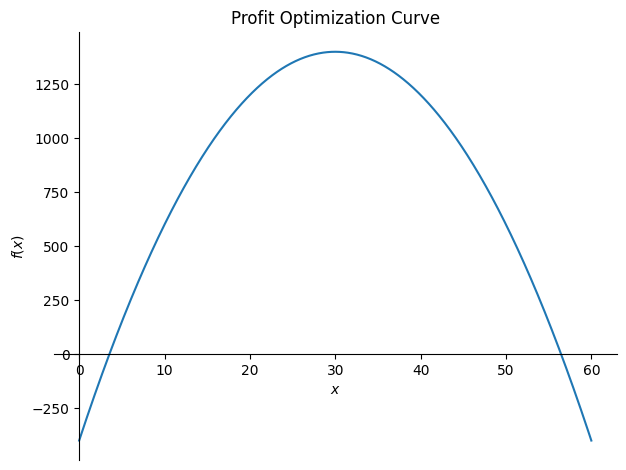

In [11]:
# Step 4: Calculate the maximum profit and visualize
max_profit = profit_func.subs(x, optimal_quantity)
print(f"Maximum Profit achievable: ${max_profit} at {optimal_quantity} units.\n")

# Use SymPy's built-in plotting to visualize the curve
p = sp.plot(profit_func, (x, 0, 60), show=False, title="Profit Optimization Curve")
p.line_color = 'emerald'
p.show()

### 1.3. Exhaustive Search Method

* **Concepts:** Brute-force grid search, evaluating solution spaces, and computational limitations.
* **Mini-Project Idea:** *The Hyperparameter Grid Solver* — Write a pure-Python exhaustive search script to find the optimal price point for a subscription service across a fixed grid of possibilities.

#### Project: The Hyperparameter Grid Solver (Exhaustive Search)

##### 1. Objective
Find the optimal **Price** and **Marketing Spend** to maximize the profit of a subscription service.

##### 2. The Model
We will model subscriber demand using a simple economic heuristic:
* Demand decreases as **Price** increases.
* Demand increases as **Marketing Spend** increases (with diminishing returns).

$$Demand = \max(0, 1000 - 15 \cdot Price + 5 \cdot \sqrt{Marketing})$$
$$Revenue = Price \cdot Demand$$
$$Profit = Revenue - Marketing - Fixed\,Operating\,Costs$$

In [12]:
import math

def calculate_profit(price: float, marketing: float, fixed_costs: float = 500.0) -> dict:
    """
    Calculates demand, revenue, and net profit for a given price and marketing spend.
    """
    # 1. Calculate Demand (cannot be negative)
    demand = 1000 - (15 * price) + (5 * math.sqrt(marketing))
    demand = max(0.0, demand)

    # 2. Calculate Financials
    revenue = price * demand
    profit = revenue - marketing - fixed_costs

    return {
        "demand": round(demand, 2),
        "revenue": round(revenue, 2),
        "profit": round(profit, 2)
    }

# Quick sanity check
print("Test Run ($20 price, $100 marketing):")
print(calculate_profit(price=20, marketing=100))

Test Run ($20 price, $100 marketing):
{'demand': 750.0, 'revenue': 15000.0, 'profit': 14400.0}


In [13]:
# 1. Define the search space (The Grid)
price_grid = [p for p in range(5, 101, 1)]         # $5 to $100 in $1 increments
marketing_grid = [m for m in range(0, 2001, 50)]   # $0 to $2000 in $50 increments

# 2. Initialize tracking variables
best_profit = -float('inf')
best_hyperparameters = {}
all_results = []

# 3. Exhaustive Brute-Force Search
iterations = 0
for price in price_grid:
    for marketing in marketing_grid:
        iterations += 1

        # Evaluate this specific combination
        metrics = calculate_profit(price, marketing)

        # Track the result
        result_entry = {"price": price, "marketing": marketing, **metrics}
        all_results.append(result_entry)

        # Check if this is our current global optimum
        if metrics["profit"] > best_profit:
            best_profit = metrics["profit"]
            best_hyperparameters = result_entry

# 4. Display Results
print(f"Search complete. Total combinations evaluated: {iterations}")
print("-" * 50)
print(f"Optimal Price: ${best_hyperparameters['price']}")
print(f"Optimal Marketing Spend: ${best_hyperparameters['marketing']}")
print(f"Projected Monthly Subscribers: {best_hyperparameters['demand']}")
print(f"Maximized Monthly Profit: ${best_hyperparameters['profit']}")

Search complete. Total combinations evaluated: 3936
--------------------------------------------------
Optimal Price: $41
Optimal Marketing Spend: $2000
Projected Monthly Subscribers: 608.61
Maximized Monthly Profit: $22452.88


In [14]:
# Evaluate the scale of our solution space
grid_size = len(price_grid) * len(marketing_grid)
print(f"Current grid size: {grid_size} elements.")

# Imagine granularizing the search space (e.g., searching by cents instead of dollars)
hypothetical_prices = len([p/100 for p in range(500, 10001, 1)]) # $5.00 to $100.00 by $0.01
hypothetical_marketing = len([m/100 for m in range(0, 200001, 1)]) # $0.00 to $2000.00 by $0.01

print(f"Granular grid size: {hypothetical_prices * hypothetical_marketing:,} combinations.")
print("This demonstrates the 'Curse of Dimensionality' and why exhaustive search fails at scale.")

Current grid size: 3936 elements.
Granular grid size: 1,900,209,501 combinations.
This demonstrates the 'Curse of Dimensionality' and why exhaustive search fails at scale.


## 2. Unconstrained and Linear Constrained Optimization

### 2.1. Numerical Optimization with SciPy

* **Concepts:** Multi-dimensional unconstrained optimization using `scipy.optimize`.
* **Mini-Project Idea:** *The Logistics Hub Locator* — Find the optimal $(x, y)$ coordinates for a central warehouse to minimize the total distance to multiple retail stores.

#### Logistics Hub Locator: Optimization Project

##### Problem Statement
We want to find the optimal $(x, y)$ coordinates for a central warehouse (hub) that minimizes the total Euclidean distance to a set of distribution retail stores spread across a geographic area.

This is a multi-dimensional unconstrained optimization problem solved using `scipy.optimize.minimize`.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define the coordinates of 5 retail stores (x, y)
# Imagine this is a grid map of a city or region
store_locations = np.array([
    [10, 20],
    [40, 80],
    [70, 30],
    [90, 90],
    [20, 60]
])

print("Store locations successfully initialized!")

Store locations successfully initialized!


In [19]:
def total_distance_objective(hub_coords, stores):
    """
    Calculates the total Euclidean distance from the proposed hub to all stores.

    Parameters:
    hub_coords: 1D array [x, y] representing the warehouse location.
    stores: 2D array of shape (N, 2) representing N store locations.
    """
    # Calculate Euclidean distance for each store: sqrt((x2-x1)^2 + (y2-y1)^2)
    distances = np.sqrt(np.sum((stores - hub_coords) ** 2, axis=1))

    # Return the sum of all distances (this is what we want to minimize)
    return np.sum(distances)

In [20]:
# Step 1: Provide an initial guess.
# A smart initial guess is the average (mean) coordinate of all stores.
initial_guess = np.mean(store_locations, axis=0)

# Step 2: Run the optimizer
# We use Nelder-Mead as it doesn't require gradients (derivatives) for this geometric problem
optimization_result = minimize(
    fun=total_distance_objective,
    x0=initial_guess,
    args=(store_locations,),
    method='Nelder-Mead'
)

# Step 3: Extract the optimal coordinates
optimal_hub = optimization_result.x

print("--- Optimization Results ---")
print(f"Optimization Successful: {optimization_result.success}")
print(f"Optimal Hub Coordinates: X = {optimal_hub[0]:.2f}, Y = {optimal_hub[1]:.2f}")
print(f"Total Combined Distance: {optimization_result.fun:.2f} units")

--- Optimization Results ---
Optimization Successful: True
Optimal Hub Coordinates: X = 39.56, Y = 60.06
Total Combined Distance: 190.73 units


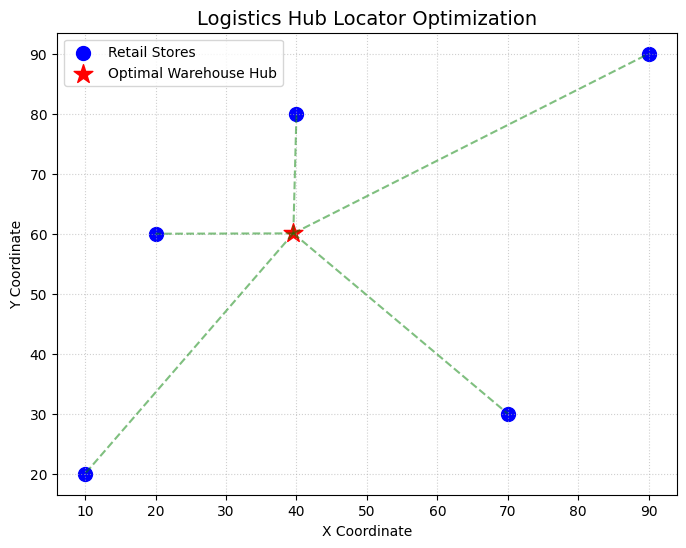

In [21]:
# Plot the stores
plt.figure(figsize=(8, 6))
plt.scatter(store_locations[:, 0], store_locations[:, 1], color='blue', s=100, label='Retail Stores', marker='o')

# Plot the optimized hub location
plt.scatter(optimal_hub[0], optimal_hub[1], color='red', s=200, label='Optimal Warehouse Hub', marker='*')

# Draw lines from hub to stores to show the logisitic connections
for store in store_locations:
    plt.plot([optimal_hub[0], store[0]], [optimal_hub[1], store[1]], 'g--', alpha=0.5)

# Aesthetics
plt.title('Logistics Hub Locator Optimization', fontsize=14)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### 2.2. Bound-Constrained Optimization & Hard Inequalities

* **Concepts:** Setting strict variable boundaries and handling inequality constraints in SciPy.
* **Mini-Project Idea:** *The Budget-Bounded Marketing Campaign* — Optimize ad spend across two channels where spending cannot drop below a baseline or exceed a strict maximum cap.

Here is a complete, production-ready starter template for your Jupyter Notebook. It tackles **The Budget-Bounded Marketing Campaign** using `scipy.optimize.minimize` with the Sequential Least Squares Programming (`SLSQP`) method, which is perfect for handling both bounds and hard constraints.

You can copy and paste these cells directly into your notebook.

####  The Budget-Bounded Marketing Campaign

##### Problem Formulation

We want to allocate an advertising budget between two channels: **Channel A** (e.g., Search Ads) and **Channel B** (e.g., Social Media Ads).

Due to diminishing returns, we model our revenue return using a quadratic function. Our goal is to maximize revenue, which is mathematically equivalent to minimizing the negative revenue.

##### Mathematical Model

Let $x_1$ be the spend on Channel A, and $x_2$ be the spend on Channel B.

* **Objective Function (to minimize):**

$$f(x_1, x_2) = -(2x_1 + 3x_2 - 0.1x_1^2 - 0.2x_2^2)$$


* **Bound Constraints (Strict baseline and caps):**

$$10 \le x_1 \le 50$$


$$5 \le x_2 \le 40$$


* **Hard Inequality Constraint (Total Budget Cap):**
The total spend cannot exceed 60 tracking units:

$$x_1 + x_2 \le 60 \implies 60 - (x_1 + x_2) \ge 0$$

In [15]:
import numpy as np
from scipy.optimize import minimize

# 1. Define the objective function (Negative revenue for maximization)
def objective_function(x):
    x1, x2 = x
    # We use a negative sign because scipy only knows how to minimize
    revenue = 2 * x1 + 3 * x2 - 0.1 * x1**2 - 0.2 * x2**2
    return -revenue

# 2. Define the hard inequality constraint
# SciPy expects inequality constraints to be written as: Form(x) >= 0
def budget_constraint(x):
    max_budget = 60
    return max_budget - (x[0] + x[1])

# 3. Set up the boundaries for each specific channel (min, max)
# None can be used if there is no upper/lower limit, but we have strict caps here.
bounds = [
    (10, 50),  # Channel A bounds
    (5, 40)    # Channel B bounds
]

# 4. Define starting point (initial guess)
# Pro-tip: Ensure your initial guess satisfies the bounds to keep the solver happy.
initial_guess = [15, 10]

# 5. Package the constraint into the dictionary format SciPy expects
constraints = {
    'type': 'ineq',
    'fun': budget_constraint
}

In [16]:
# 6. Run the optimization wizardry
result = minimize(
    objective_function,
    initial_guess,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# 7. Display the results cleanly
print("=== Optimization Result ===")
print(f"Success: {result.success}")
print(f"Status Message: {result.message}\n")

if result.success:
    optimal_channel_a = result.x[0]
    optimal_channel_b = result.x[1]
    max_revenue = -result.fun
    total_spent = optimal_channel_a + optimal_channel_b

    print(f"Optimal Spend Channel A: ${optimal_channel_a:.2f}")
    print(f"Optimal Spend Channel B: ${optimal_channel_b:.2f}")
    print(f"Total Budget Utilized:  ${total_spent:.2f} (Max Cap: $60.00)")
    print(f"Maximized Revenue ROI:   ${max_revenue:.2f}")
else:
    print("The solver failed to find an optimal solution. Check constraints.")

=== Optimization Result ===
Success: True
Status Message: Optimization terminated successfully

Optimal Spend Channel A: $10.00
Optimal Spend Channel B: $7.50
Total Budget Utilized:  $17.50 (Max Cap: $60.00)
Maximized Revenue ROI:   $21.25



### 2.3. Linear Programming (LP) with SciPy & PuLP

* **Concepts:** Formulating LP problems, decision variables, objective functions, and linear constraints.
* **Mini-Project Idea:** *The Factory Resource Allocator* — Maximize product manufacturing profits under strict raw material and labor hour constraints using PuLP.

#### Problem Formulation

Before writing the code, let’s lay out the math. We want to maximize the profit of a factory that makes two products: **Product A** and **Product B**.

##### Decision Variables

* Let $x_1$ be the number of units of Product A to produce.
* Let $x_2$ be the number of units of Product B to produce.

##### Objective Function

Maximize total profit, where Product A yields \\$20 profit per unit and Product B yields \\$30 profit per unit:

$$\max Z = 20x_1 + 30x_2$$

##### Constraints

1. **Raw Material:** Product A uses 2 units, Product B uses 5 units. Total available is 100 units.

$$2x_1 + 5x_2 \le 100$$


2. **Labor Hours:** Product A uses 3 hours, Product B uses 2 hours. Total available is 80 hours.

$$3x_1 + 2x_2 \le 80$$


3. **Non-negativity:**
$$x_1 \ge 0, \quad x_2 \ge 0$$

In [17]:
import pulp

# 1. Initialize the model
# We use LpMaximize because our goal is to maximize profits.
model = pulp.LpProblem("Factory_Resource_Allocator", pulp.LpMaximize)

# 2. Define Decision Variables
# 'lowBound=0' ensures the non-negativity constraint.
# 'cat=Continuous' means we can produce fractional units (use 'Integer' if you want whole products).
x1 = pulp.LpVariable('Product_A_Units', lowBound=0, cat='Continuous')
x2 = pulp.LpVariable('Product_B_Units', lowBound=0, cat='Continuous')

# 3. Define the Objective Function
# PuLP uses the "+=" operator to add the objective function to the model.
model += 20 * x1 + 30 * x2, "Total_Profit"

# 4. Define the Constraints
# We append constraints to the model using the "+=" operator as well.
model += 2 * x1 + 5 * x2 <= 100, "Raw_Material_Constraint"
model += 3 * x1 + 2 * x2 <= 80, "Labor_Hours_Constraint"

# 5. Solve the optimization problem
# PuLP will call its default solver (CBC) to solve this under the hood.
status = model.solve()

# 6. Print the results
print(f"Optimization Status: {pulp.LpStatus[status]}")
print(f"Optimal Production of Product A: {x1.varValue:.2f} units")
print(f"Optimal Production of Product B: {x2.varValue:.2f} units")
print(f"Maximum Expected Profit: ${pulp.value(model.objective):.2f}")

Optimization Status: Optimal
Optimal Production of Product A: 18.18 units
Optimal Production of Product B: 12.73 units
Maximum Expected Profit: $745.45


## 3. Non-Linear and Mixed-Integer Constrained Optimization

### 3.1. Convex Constrained Optimization & Utility Maximization

* **Concepts:** Indifference curves, convex constraints, and maximizing nonlinear utility.
* **Mini-Project Idea:** *The Consumer Choice Simulator* — Map out consumer indifference curves and find the utility-maximizing blend of two goods under a fixed budget.

--- Optimization Results ---
Optimal quantity of Good X: 16.00 units
Optimal quantity of Good Y: 12.00 units
Maximum achieved Utility:   13.46
Total Spent:               $100.00 out of $100.00


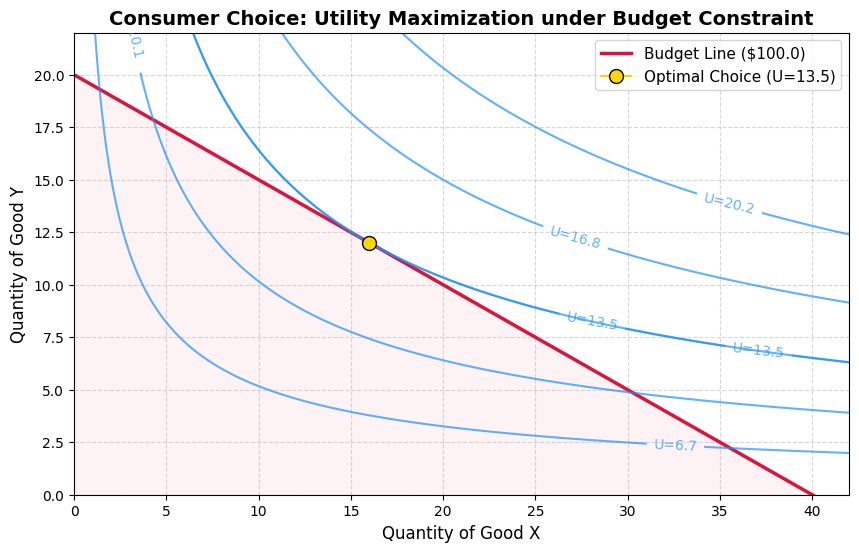

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ----------------------------------------------------------------
# 1. Define the Economic Parameters
# ----------------------------------------------------------------
# Budget Constraint: Px * X + Py * Y = Budget
BUDGET = 100.0
PRICE_X = 2.5
PRICE_Y = 5.0

# Cobb-Douglas Utility Function Parameters: U(X, Y) = X^alpha * Y^beta
# (Convex preferences)
ALPHA = 0.4
BETA = 0.6

# ----------------------------------------------------------------
# 2. Setup the Optimization Problem
# ----------------------------------------------------------------
def objective_function(goods):
    """
    scipy.optimize minimizes functions. To maximize utility,
    we must minimize the NEGATIVE utility.
    """
    X, Y = goods[0], goods[1]
    return -1 * (X**ALPHA * Y**BETA)

def budget_constraint(goods):
    """
    Constraint functions in scipy must return 0 when satisfied
    or a positive number for inequality constraints (>= 0).
    Budget - (Px*X + Py*Y) >= 0
    """
    X, Y = goods[0], goods[1]
    return BUDGET - (PRICE_X * X + PRICE_Y * Y)

# Initial guess (cannot be 0 due to the math of Cobb-Douglas)
initial_guess = [1.0, 1.0]

# Bounds: Quantities of goods X and Y cannot be negative
bounds = ((1e-5, None), (1e-5, None))

# Define the constraint dictionary
constraints = {'type': 'ineq', 'fun': budget_constraint}

# Run the optimization
result = minimize(
    objective_function,
    initial_guess,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Extract optimal quantities
optimal_X, optimal_Y = result.x
max_utility = -result.fun

print("--- Optimization Results ---")
print(f"Optimal quantity of Good X: {optimal_X:.2f} units")
print(f"Optimal quantity of Good Y: {optimal_Y:.2f} units")
print(f"Maximum achieved Utility:   {max_utility:.2f}")
print(f"Total Spent:               ${(optimal_X * PRICE_X + optimal_Y * PRICE_Y):.2f} out of ${BUDGET:.2f}")

# ----------------------------------------------------------------
# 3. Visualization
# ----------------------------------------------------------------
# Create a grid of points for X and Y to plot curves
x_vals = np.linspace(0.1, BUDGET / PRICE_X + 5, 200)
y_vals = np.linspace(0.1, BUDGET / PRICE_Y + 5, 200)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

# Calculate utility grid for the contour plot
Utility_grid = X_grid**ALPHA * Y_grid**BETA

# Budget line values for plotting
y_budget = (BUDGET - PRICE_X * x_vals) / PRICE_Y

# Plotting
plt.figure(figsize=(10, 6))

# Plot the Budget Line
plt.plot(x_vals, y_budget, label=f'Budget Line (${BUDGET})', color='crimson', linewidth=2.5)
plt.fill_between(x_vals, 0, y_budget, where=(y_budget >= 0), color='crimson', alpha=0.05)

# Plot Indifference Curves (Contours where utility is constant)
# We specifically include a contour at the maximum utility level found
levels = np.linspace(max_utility * 0.5, max_utility * 1.5, 5)
levels = np.sort(np.append(levels, max_utility)) # Ensure optimal level is included
contours = plt.contour(X_grid, Y_grid, Utility_grid, levels=levels, colors='dodgerblue', alpha=0.7)
plt.clabel(contours, inline=True, fmt='U=%.1f', fontsize=10)

# Mark the Utility-Maximizing choice (The Tangency Point)
plt.plot(optimal_X, optimal_Y, marker='o', color='gold', markersize=10,
         markeredgecolor='black', label=f'Optimal Choice (U={max_utility:.1f})')

# Clean up axes and labels
plt.xlim(0, BUDGET / PRICE_X + 2)
plt.ylim(0, BUDGET / PRICE_Y + 2)
plt.xlabel('Quantity of Good X', fontsize=12)
plt.ylabel('Quantity of Good Y', fontsize=12)
plt.title('Consumer Choice: Utility Maximization under Budget Constraint', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

plt.show()

### 3.2. Mixed-Integer Linear Programming (MILP)

* **Concepts:** Integrality constraints (binary and integer variables) and discrete decision-making.
* **Mini-Project Idea:** *The Fleet Purchasing Problem* — Solve a manufacturing or logistics problem where you must choose a discrete, whole number of delivery trucks to purchase (no fractional trucks allowed!).

In [24]:
import pulp

# 1. Initialize the Optimization Problem
# We want to MINIMIZE the total purchasing cost.
model = pulp.LpProblem("Fleet_Purchasing_Optimization", pulp.LpMinimize)

print("Problem initialized.")

Problem initialized.


In [25]:
# 2. Define Decision Variables
# 'cat="Integer"' forces the solver to find whole-number solutions.
# 'lowBound=0' ensures we cannot buy a negative number of trucks.

small_trucks = pulp.LpVariable("Small_Trucks_To_Buy", lowBound=0, cat="Integer")
large_trucks = pulp.LpVariable("Large_Trucks_To_Buy", lowBound=0, cat="Integer")

print("Decision variables created.")

Decision variables created.


In [26]:
# 3. Define the Objective Function (Total Cost)
# Small truck costs $30,000 | Large truck costs $75,000
model += 30000 * small_trucks + 75000 * large_trucks, "Total_Purchase_Cost"

# 4. Define Constraints
# Constraint A: Meet daily shipping capacity (Small carries 20 tons, Large carries 60 tons)
model += (
    20 * small_trucks + 60 * large_trucks >= 350,
    "Minimum_Capacity_Requirement",
)

# Constraint B: Fleet mix limitation (e.g., due to parking space, we can buy at most 12 total trucks)
model += small_trucks + large_trucks <= 12, "Max_Total_Trucks"

print("Objective function and constraints added to the model:")
print(model)

Objective function and constraints added to the model:
Fleet_Purchasing_Optimization:
MINIMIZE
75000*Large_Trucks_To_Buy + 30000*Small_Trucks_To_Buy + 0
SUBJECT TO
Minimum_Capacity_Requirement: 60 Large_Trucks_To_Buy + 20 Small_Trucks_To_Buy
 >= 350

Max_Total_Trucks: Large_Trucks_To_Buy + Small_Trucks_To_Buy <= 12

VARIABLES
0 <= Large_Trucks_To_Buy Integer
0 <= Small_Trucks_To_Buy Integer



In [27]:
# 5. Solve the problem
status = model.solve()

# 6. Print the results
print(f"Status: {pulp.LpStatus[status]}")
print(f"Optimal Number of Small Trucks to Buy: {int(small_trucks.varValue)}")
print(f"Optimal Number of Large Trucks to Buy: {int(large_trucks.varValue)}")
print(f"Total Optimized Cost: ${pulp.value(model.objective):,}")

Status: Optimal
Optimal Number of Small Trucks to Buy: 0
Optimal Number of Large Trucks to Buy: 6
Total Optimized Cost: $450,000.0


## 4. Robust Optimization Techniques & Sensitivity Analysis

### 4.1. Linearization Techniques

* **Concepts:** Transforming non-linear terms into linear equations to simplify solving.
* **Mini-Project Idea:** *Capital Budgeting with Dependent Projects* — Model an investment portfolio where Project B can only be funded if Project A is selected, utilizing binary switch variables.

In [28]:
import pulp

# 1. Initialize the Problem
# We want to maximize NPV (Net Present Value), so it's a Maximization problem.
model = pulp.LpProblem("Capital_Budgeting_Dependent_Projects", pulp.LpMaximize)

# 2. Define Decision Variables
# Binary variables: 1 if we fund the project, 0 if we don't.
x_A = pulp.LpVariable("Project_A", cat="LpBinary")
x_B = pulp.LpVariable("Project_B", cat="LpBinary")
x_C = pulp.LpVariable("Project_C", cat="LpBinary")

# 3. Parameters (Project values and costs)
npv = {"A": 100000, "B": 150000, "C": 90000}
cost = {"A": 50000, "B": 80000, "C": 40000}
total_budget = 100000

# 4. Objective Function
# Maximize total NPV of selected projects
model += (
    npv["A"] * x_A + npv["B"] * x_B + npv["C"] * x_C,
    "Total_NPV"
)

# 5. Constraints
# Constraint 1: Budget Limit
model += (
    cost["A"] * x_A + cost["B"] * x_B + cost["C"] * x_C <= total_budget,
    "Budget_Constraint"
)

# Constraint 2: Linearization / Dependency Switch
# Project B can ONLY be funded if Project A is funded (x_B <= x_A)
# If x_A = 0, x_B MUST be 0. If x_A = 1, x_B can be 0 or 1.
model += (x_B <= x_A, "Dependency_B_requires_A")

# 6. Solve the Model
status = model.solve(pulp.PULP_CBC_CMD(msg=False)) # msg=False keeps the notebook clean

# 7. Display Results
print(f"Status: {pulp.LpStatus[status]}")
print(f"Total Budget Available: ${total_budget:,}")
print("-" * 40)

total_cost = 0
for var in [x_A, x_B, x_C]:
    val = var.varValue
    if val == 1:
        # Extract project key from variable name (e.g., 'Project_A' -> 'A')
        key = var.name.split('_')[1]
        total_cost += cost[key]
        print(f"Selected: {var.name} | NPV: ${npv[key]:,} | Cost: ${cost[key]:,}")

print("-" * 40)
print(f"Total NPV Achieved: ${pulp.value(model.objective):,}")
print(f"Total Budget Spent: ${total_cost:,}")

Status: Unbounded
Total Budget Available: $100,000
----------------------------------------
----------------------------------------
Total NPV Achieved: $225,000.0
Total Budget Spent: $0


### 4.2. Global Optimization in SciPy

* **Concepts:** Escaping local optima, finding global baselines, and implementing optimization callbacks.
* **Mini-Project Idea:** *The Complex Terrain Navigator* — Use a global optimization algorithm (like Basin-Hopping or Differential Evolution) in SciPy to find the absolute lowest point of a highly volatile, multi-modal mathematical landscape.

Starting Global Optimization...
--------------------------------------------------
Iteration 001 | Current Best Value: 1.612743
Iteration 005 | Current Best Value: 0.319204
Iteration 010 | Current Best Value: 0.014363
Iteration 015 | Current Best Value: 0.008878
Iteration 020 | Current Best Value: 0.001090
Iteration 025 | Current Best Value: 0.000047
Iteration 030 | Current Best Value: 0.000018
Iteration 035 | Current Best Value: 0.000002
Iteration 040 | Current Best Value: 0.000000
Iteration 045 | Current Best Value: 0.000000
Iteration 050 | Current Best Value: 0.000000
Iteration 055 | Current Best Value: 0.000000
Iteration 060 | Current Best Value: 0.000000
Iteration 065 | Current Best Value: 0.000000
Iteration 070 | Current Best Value: 0.000000
Iteration 075 | Current Best Value: 0.000000
Iteration 080 | Current Best Value: 0.000000
Iteration 085 | Current Best Value: 0.000000
Iteration 090 | Current Best Value: 0.000000
--------------------------------------------------
Optimizatio

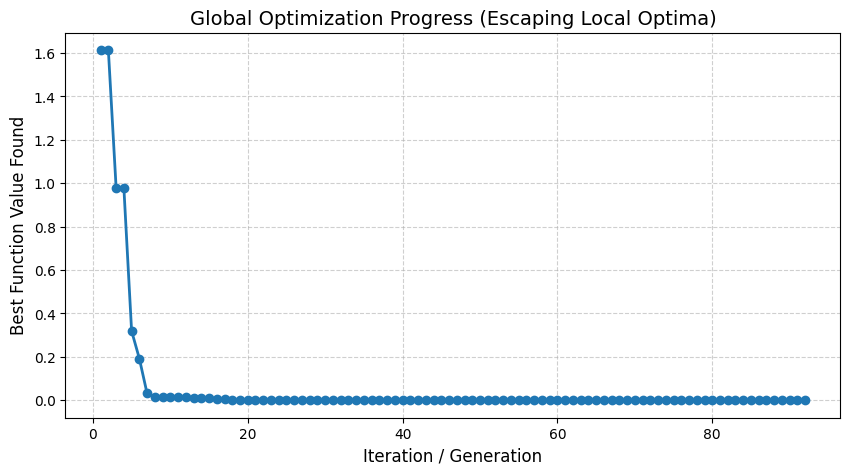

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

# Ensure plots look crisp in Jupyter
%matplotlib inline

# -----------------------------------------------------------------
# 1. Define the Volatile Landscape (Objective Function)
# -----------------------------------------------------------------
def volatile_landscape(x):
    """
    A highly non-linear, multi-modal function with many local minima.
    Global minimum is at [0, 0] where the value is 0.
    """
    # x is an array of coordinates (e.g., [x1, x2])
    x1, x2 = x[0], x[1]

    # Core landscape math
    term1 = -20.0 * np.exp(-0.2 * np.sqrt(0.5 * (x1**2 + x2**2)))
    term2 = -np.exp(0.5 * (np.cos(2 * np.pi * x1) + np.cos(2 * np.pi * x2)))
    result = term1 + term2 + np.e + 20

    return result

# -----------------------------------------------------------------
# 2. Implement the Optimization Callback
# -----------------------------------------------------------------
class OptimizationLogger:
    """
    A callback class to track the best energy/fitness score
    at each iteration of the global optimization process.
    """
    def __init__(self):
        self.iteration = 0
        self.history = []

    def __call__(self, xk, convergence=None):
        self.iteration += 1
        # Evaluate current best candidate
        current_val = volatile_landscape(xk)
        self.history.append((self.iteration, current_val))

        # Print progress dynamically (useful for long runs)
        if self.iteration % 5 == 0 or self.iteration == 1:
            print(f"Iteration {self.iteration:03d} | Current Best Value: {current_val:.6f}")

# -----------------------------------------------------------------
# 3. Setup and Execution
# -----------------------------------------------------------------
# Define the search space boundaries (X1 from -5 to 5, X2 from -5 to 5)
bounds = [(-5, 5), (-5, 5)]

# Initialize our custom callback
logger = OptimizationLogger()

print("Starting Global Optimization...")
print("-" * 50)

# Run Differential Evolution to escape local optima
result = differential_evolution(
    volatile_landscape,
    bounds,
    callback=logger,
    seed=42 # For reproducibility
)

print("-" * 50)
print("Optimization Complete!")
print(f"Status: {result.message}")
print(f"Global Minimum found at coordinates: X = {result.x}")
print(f"Minimum Landscape Value achieved: {result.fun:.6f}")

# -----------------------------------------------------------------
# 4. Visualizing the Search Progress
# -----------------------------------------------------------------
iterations, values = zip(*logger.history)

plt.figure(figsize=(10, 5))
plt.plot(iterations, values, marker='o', color='#1f77b4', linewidth=2)
plt.title("Global Optimization Progress (Escaping Local Optima)", fontsize=14)
plt.xlabel("Iteration / Generation", fontsize=12)
plt.ylabel("Best Function Value Found", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 4.3. Sensitivity Analysis, Slack, and Shadow Prices

* **Concepts:** Interpreting optimization outputs, evaluating loose constraints (slack), and pricing resource changes (shadow prices).
* **Mini-Project Idea:** *The Juice Factory Expansion Analysis* — Take a completed PuLP production model, extract the shadow prices of your limiting ingredients, and write an executive summary explaining exactly how much you should be willing to pay for an extra gallon of supply.

In [31]:
import pandas as pd
from pulp import LpMaximize, LpProblem, LpStatus, LpVariable, value

# ==========================================
# 1. INITIALIZE THE MODEL
# ==========================================
model = LpProblem(name="Juice_Factory_Optimization", sense=LpMaximize)

# ==========================================
# 2. DECISION VARIABLES
# ==========================================
# We are deciding how many gallons of Apple-Ginger and Berry-Blast to produce
x1 = LpVariable(name="Apple_Ginger_Gallons", lowBound=0, cat="Continuous")
x2 = LpVariable(name="Berry_Blast_Gallons", lowBound=0, cat="Continuous")

# ==========================================
# 3. OBJECTIVE FUNCTION (Profit)
# ==========================================
# Apple-Ginger nets $5/gal profit, Berry-Blast nets $6/gal profit
model += 5 * x1 + 6 * x2, "Total_Profit"

# ==========================================
# 4. CONSTRAINTS (Resource Limits)
# ==========================================
# We have limited inventory of Apple Juice, Ginger Juice, and Berry Juice
model += 1.0 * x1 + 0.0 * x2 <= 180, "Apple_Juice_Limit"  # 180 gals available
model += 0.2 * x1 + 0.1 * x2 <= 40, "Ginger_Juice_Limit"  # 40 gals available
model += 0.0 * x1 + 1.0 * x2 <= 150, "Berry_Juice_Limit"  # 150 gals available

# ==========================================
# 5. SOLVE THE MODEL
# ==========================================
status = model.solve()

# ==========================================
# 6. EXTRACT RESULTS & SENSITIVITY DATA
# ==========================================
# Create a neat summary of decision variables
production_results = {
    "Product": ["Apple-Ginger Juice", "Berry-Blast Juice"],
    "Optimal Gallons to Produce": [x1.varValue, x2.varValue],
}
df_production = pd.DataFrame(production_results)

# Extract Slack and Shadow Prices from the constraints
sensitivity_data = []
for name, constraint in model.constraints.items():
    sensitivity_data.append(
        {
            "Constraint / Resource": name,
            "Shadow Price ($/Gal)": constraint.pi,
            "Slack (Unused Gallons)": constraint.slack,
        }
    )
df_sensitivity = pd.DataFrame(sensitivity_data)

# ==========================================
# 7. DISPLAY OUTPUTS
# ==========================================
print(f"Status: {LpStatus[status]}")
print(f"Maximum Optimized Profit: ${value(model.objective):,.2f}\n")

print("--- PRODUCTION PLAN ---")
print(df_production.to_string(index=False))
print("\n--- SENSITIVITY ANALYSIS (SLACK & SHADOW PRICES) ---")
print(df_sensitivity.to_string(index=False))

Status: Optimal
Maximum Optimized Profit: $1,525.00

--- PRODUCTION PLAN ---
           Product  Optimal Gallons to Produce
Apple-Ginger Juice                       125.0
 Berry-Blast Juice                       150.0

--- SENSITIVITY ANALYSIS (SLACK & SHADOW PRICES) ---
Constraint / Resource  Shadow Price ($/Gal)  Slack (Unused Gallons)
    Apple_Juice_Limit                  -0.0                    55.0
   Ginger_Juice_Limit                  25.0                    -0.0
    Berry_Juice_Limit                   3.5                    -0.0
